## 16 Recommendation System
### Recommendation System
By **Mohan Sirumalla**
***

**Data Description:**

Unique ID of each anime.\
Anime title.\
Anime broadcast type, such as TV, OVA, etc.\
anime genre.\
The number of episodes of each anime.\
The average rating for each anime compared to the number of users who gave ratings.


Number of community members for each anime.\
**Objective:**
The objective of this assignment is to implement a recommendation system using cosine similarity on an anime dataset. \
**Dataset:**
Use the Anime Dataset which contains information about various anime, including their titles, genres,No.of episodes and user ratings etc.


### Data Preprocessing:

Load the dataset into a suitable data structure (e.g., pandas DataFrame).\
Handle missing values, if any.\
Explore the dataset to understand its structure and attributes.

In [54]:
import os
# 1. Set environment variable BEFORE importing sklearn to suppress warning
os.environ["OMP_NUM_THREADS"] = "1"
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print('Loaded the basic libraries')

Loaded the basic libraries


In [55]:
# Fro formated output
# Define ANSI codes for clarity
BOLD = '\033[1m'
END = '\033[0m' # Resets the format

In [56]:
df= pd.read_csv('16_anime.csv')
df.head() # display 1st 5  observations

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [57]:
print(f"Rows: {df.shape[0]} and Columns : {df.shape[0]}")

Rows: 12294 and Columns : 12294


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [59]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [60]:
df.columns

Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='object')

In [61]:
# Check Duplicate Records if any
if not df.duplicated().any():
    print("No Duplicates")
else:
    print("Duplicate records")

if df.isnull().any().any():
    print("Columns with null values and their counts:")
    # The original logic, slightly refined for clarity
    null_counts = df.loc[:, df.isnull().any()].isnull().sum()
    print(null_counts)
else:
    print("No null values found in the DataFrame.")

No Duplicates
Columns with null values and their counts:
genre      62
type       25
rating    230
dtype: int64


In [62]:
(df.isnull().sum()/len(df))*100

anime_id    0.000000
name        0.000000
genre       0.504311
type        0.203351
episodes    0.000000
rating      1.870831
members     0.000000
dtype: float64


So out of our features, the genre, type and ratings have some missing values that need to be dealt with. Further, the episodes is object type that needs to be looked into.

In [63]:
for col in df.columns:
    print(f"Unique values for {col}: {len(df[col].unique())}")

Unique values for anime_id: 12294
Unique values for name: 12292
Unique values for genre: 3265
Unique values for type: 7
Unique values for episodes: 187
Unique values for rating: 599
Unique values for members: 6706



All our anime IDs are unique. There are 2 anime's that have distinct IDs but same name

In [64]:
for col in df.columns:
    print(f"Unique values for {col}: {df[col].unique()}")

Unique values for anime_id: [32281  5114 28977 ...  5621  6133 26081]
Unique values for name: ['Kimi no Na wa.' 'Fullmetal Alchemist: Brotherhood' 'Gintama°' ...
 'Violence Gekiga David no Hoshi'
 'Violence Gekiga Shin David no Hoshi: Inma Densetsu'
 'Yasuji no Pornorama: Yacchimae!!']
Unique values for genre: ['Drama, Romance, School, Supernatural'
 'Action, Adventure, Drama, Fantasy, Magic, Military, Shounen'
 'Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen' ...
 'Hentai, Sports' 'Drama, Romance, School, Yuri' 'Hentai, Slice of Life']
Unique values for type: ['Movie' 'TV' 'OVA' 'Special' 'Music' 'ONA' nan]
Unique values for episodes: ['1' '64' '51' '24' '10' '148' '110' '13' '201' '25' '22' '75' '4' '26'
 '12' '27' '43' '74' '37' '2' '11' '99' 'Unknown' '39' '101' '47' '50'
 '62' '33' '112' '23' '3' '94' '6' '8' '14' '7' '40' '15' '203' '77' '291'
 '120' '102' '96' '38' '79' '175' '103' '70' '153' '45' '5' '21' '63' '52'
 '28' '145' '36' '69' '60' '178' '114' '35' '61' 

We notice a Unknown value in episodes

In [65]:
print(f"Unique values of episodes {len(df[df['episodes'] == 'Unknown'])}")

Unique values of episodes 340



About 340 of our animes have unknown number of episodes. We will replace them with null values and convert the episodes to numeric type for further analysis.

In [66]:
df['episodes'] = df['episodes'].replace('Unknown', np.nan)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  11954 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB



So our dataset comprises of movies, tv shows, OVAs (original video animations), special, music and ONAs (original net animations). There are 25 empty NaN that will need to be dealt with.

In [67]:
df[['episodes', 'rating', 'members']].describe()

,rating,members
count,12064.000000,1.229400e+04
mean,6.473902,1.807134e+04
std,1.026746,5.482068e+04
min,1.670000,5.000000e+00
25%,5.880000,2.250000e+02
50%,6.570000,1.550000e+03
75%,7.180000,9.437000e+03
max,10.000000,1.013917e+06


**Data Insights**

* **Episodes:** Most anime have fewer than 12 episodes, but a few long-running series (up to 1,818 episodes) significantly raise the average.
* **Ratings:** The majority of anime are rated between 5.88 and 7.18, with an average rating of 6.47. Only a few anime achieve exceptional ratings close to 10.
* **Members:** Most anime have small communities (median 1,550 members), but a few extremely popular titles exceed 1 million members, dominating the dataset.

These insights indicate that while short anime are common, long-running series and highly-rated anime tend to attract larger audiences.

In [68]:
numeric_columns = df[['rating', 'members']]
numeric_columns.describe()

,rating,members
count,12064.000000,1.229400e+04
mean,6.473902,1.807134e+04
std,1.026746,5.482068e+04
min,1.670000,5.000000e+00
25%,5.880000,2.250000e+02
50%,6.570000,1.550000e+03
75%,7.180000,9.437000e+03
max,10.000000,1.013917e+06


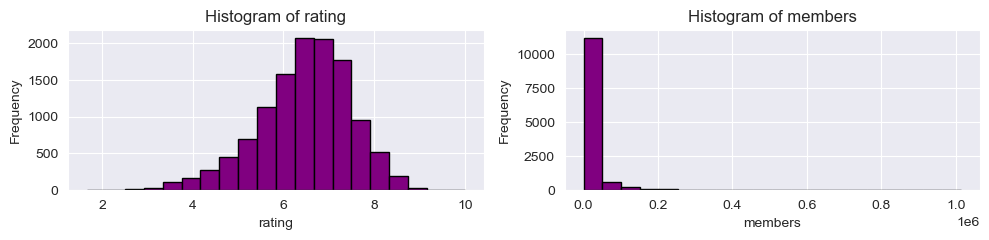

In [69]:
# Create a figure and axis array with subplots
fig, axes = plt.subplots(7, 2, figsize=(10, 15))

# Flatten the 2D axis array to make it easier to iterate
axes = axes.flatten()

# Loop through each numeric column and plot its histogram
for i, col in enumerate(numeric_columns.columns):
    axes[i].hist(numeric_columns[col], bins=20, color='purple', edgecolor='black')
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# 4. Identify and remove unused subplots
for ax in axes:
    # Check if the axis is empty (no artists/children)
    if not ax.has_data(): # A simpler check for general use
    # Alternatively, check len(ax.get_children()) == 0, though not always perfect if text or other elements are present by default.
        fig.delaxes(ax) # Remove the axis from the figure


# Adjust layout for better spacing
plt.tight_layout()
plt.show()

### Feature Extraction:

Decide on the features that will be used for computing similarity (e.g., genres, user ratings).\
Convert categorical features into numerical representations if necessary.\
Normalize numerical features if required.

In [70]:
#Convert categorical features into numerical representations if necessary.
df['episodes'] = df['episodes'].astype(float)
numeric_columns = df[['episodes','rating', 'members']]

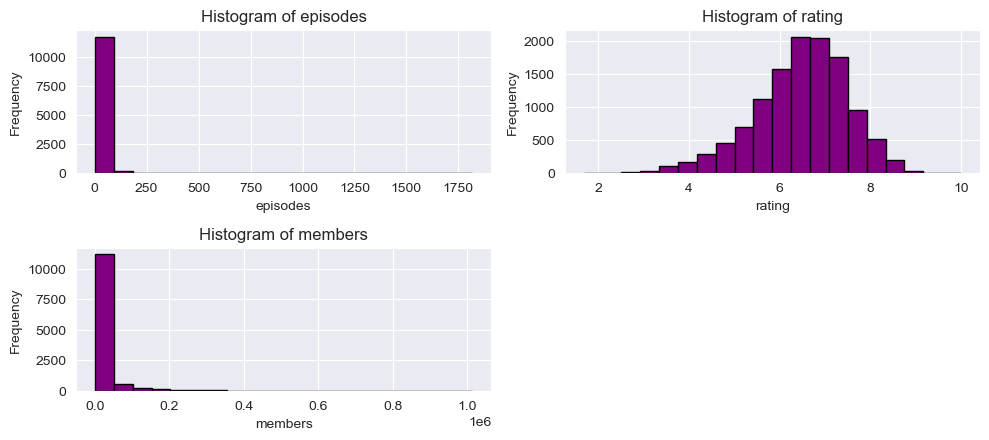

In [71]:
# Create a figure and axis array with subplots
fig, axes = plt.subplots(7, 2, figsize=(10, 15))

# Flatten the 2D axis array to make it easier to iterate
axes = axes.flatten()

# Loop through each numeric column and plot its histogram
for i, col in enumerate(numeric_columns.columns):
    axes[i].hist(numeric_columns[col], bins=20, color='purple', edgecolor='black')
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# 4. Identify and remove unused subplots
for ax in axes:
    # Check if the axis is empty (no artists/children)
    if not ax.has_data(): # A simpler check for general use
    # Alternatively, check len(ax.get_children()) == 0, though not always perfect if text or other elements are present by default.
        fig.delaxes(ax) # Remove the axis from the figure


# Adjust layout for better spacing
plt.tight_layout()
plt.show()

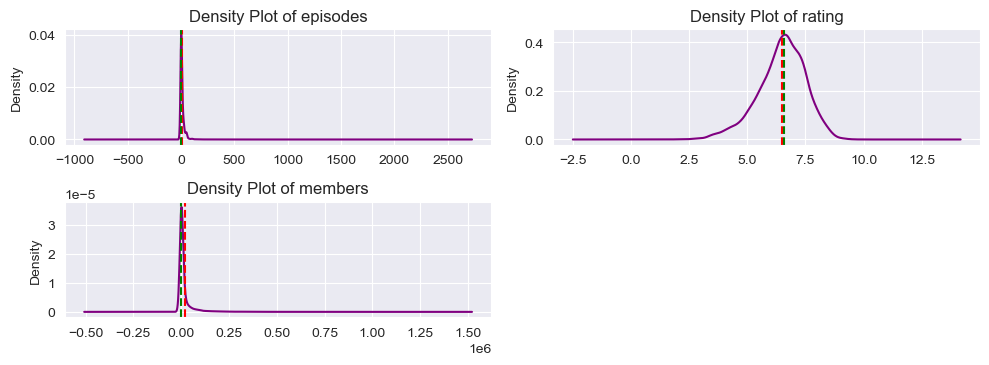

In [72]:
#Density Plots

# Create a figure and axis array with subplots
fig, axes = plt.subplots(7, 2, figsize=(10, 12))

# Flatten the 2D axis array to make it easier to iterate
axes = axes.flatten()

# Loop through each numeric column and plot its histogram
for i, column in enumerate(numeric_columns.columns):
    ax = numeric_columns[column].plot.density(ax = axes[i], color='purple')
    ax.axvline(numeric_columns[column].mean(), color = 'red', linestyle ='--')
    ax.axvline(numeric_columns[column].median(), color = 'green', linestyle ='--')
    ax.set_title(f'Density Plot of {column}')

# 4. Identify and remove unused subplots
for ax in axes:
    # Check if the axis is empty (no artists/children)
    if not ax.has_data(): # A simpler check for general use
    # Alternatively, check len(ax.get_children()) == 0, though not always perfect if text or other elements are present by default.
        fig.delaxes(ax) # Remove the axis from the figure


# Adjust layout for better spacing
plt.tight_layout()
plt.show()

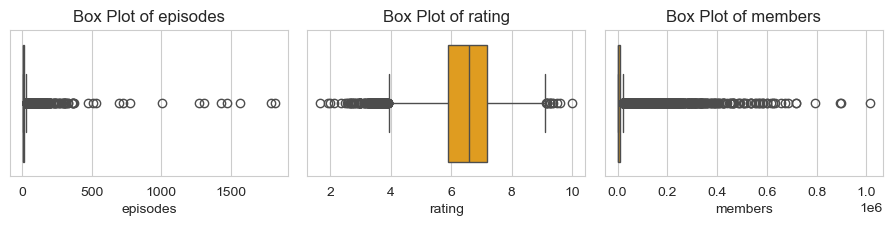

In [73]:
plt.figure(figsize=(12,8))
sns.set_style(style='whitegrid')
for index,col in enumerate(numeric_columns.columns):
    plt.subplot(4,4,index+1)
    sns.boxplot(x=col,data=numeric_columns,color= 'orange')
    plt.title(f'Box Plot of {col}')
plt.tight_layout()    
plt.show()


<Axes: >

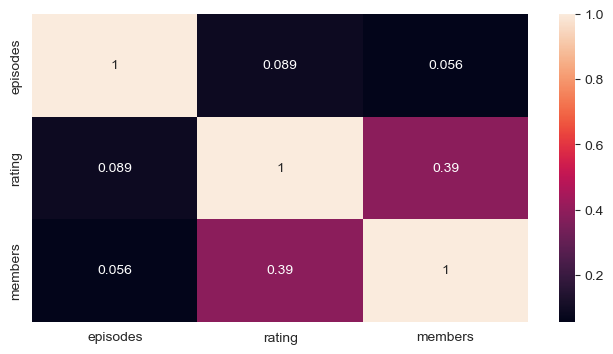

In [74]:
plt.figure(figsize=(8,4))
corrmat=numeric_columns.corr()
sns.heatmap(corrmat, annot=True)

Categorical Variables Analysis

In [75]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1.0,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64.0,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24.0,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51.0,9.16,151266


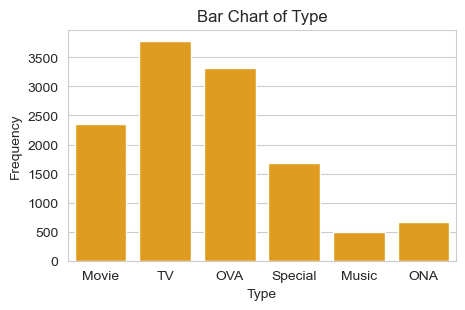

In [76]:
# Assuming 'dataset' is your DataFrame and 'Type' is the column you want to plot
plt.figure(figsize=(5, 3))
sns.countplot(x='type', data=df, color = 'orange')
plt.title('Bar Chart of Type')
plt.xlabel('Type')
plt.ylabel('Frequency')
plt.show()

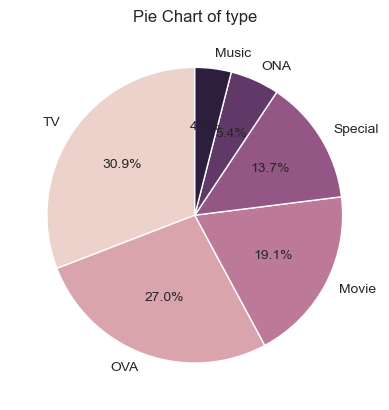

In [77]:
df['type'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.cubehelix_palette(), startangle=90)
plt.title(f'Pie Chart of type')
plt.ylabel('')
plt.show()

**Insights**

  * **TV** anime is the most common format (30.9%), indicating that full-length series dominate the dataset.
  * **OVA** (27.0%) and Movies (19.1%) are also significant.
  * **Specials** (13.7%) are relatively common, often including extra episodes or bonus content.
  * **ONA** (8.4%) and **Music** (4.0%) have the smallest share, implying that web-only and music-related anime are less frequent.


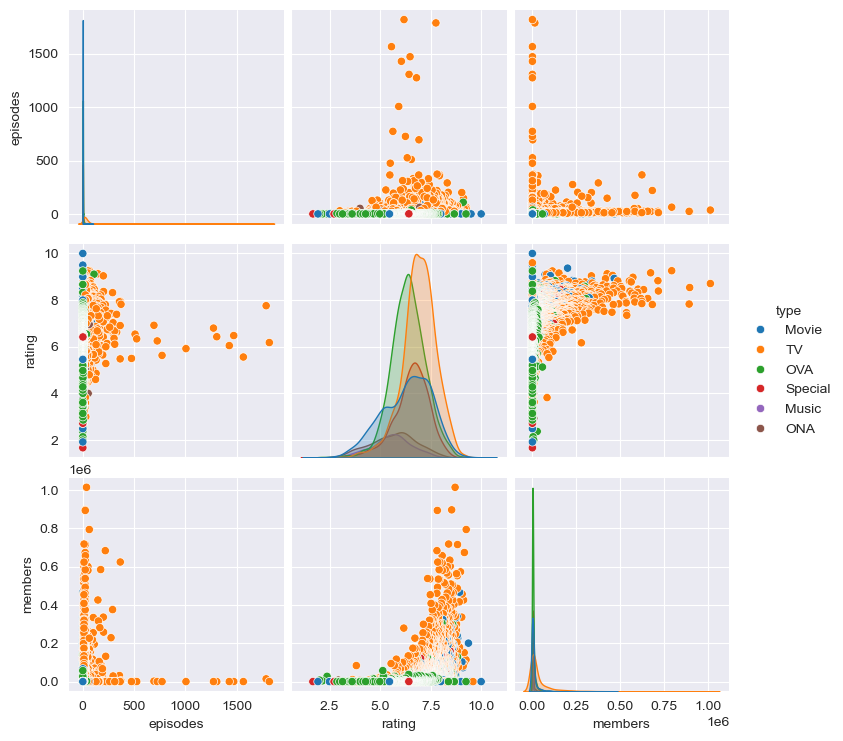

In [78]:
#Format the plot background and scatter plots for all the variables
sns.set_style(style='darkgrid')
sns.pairplot(df, vars = list(numeric_columns.columns), hue = 'type')

In [79]:

genre_set =  df['genre'].str.split(',', expand=True)
genre_set.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Drama,Romance,School,Supernatural,None,None,None,None,None,None,None,None,None
1,Action,Adventure,Drama,Fantasy,Magic,Military,Shounen,None,None,None,None,None,None
2,Action,Comedy,Historical,Parody,Samurai,Sci-Fi,Shounen,None,None,None,None,None,None
3,Sci-Fi,Thriller,None,None,None,None,None,None,None,None,None,None,None
4,Action,Comedy,Historical,Parody,Samurai,Sci-Fi,Shounen,None,None,None,None,None,None


In [80]:

# Concatenate columns 1 to 12 as rows under index 0
appended_rows = pd.concat([genre_set[i] for i in range(1, 13)], ignore_index=True)

# Create a new DataFrame with the appended rows under index 0
genre_final = pd.DataFrame({'genre': appended_rows})
genre_final.head(20)



,genre
0,Romance
1,Adventure
2,Comedy
3,Thriller
4,Comedy
5,Drama
6,Adventure
7,Military
8,Comedy
9,Comedy


In [81]:
genre_final['genre'].unique().shape

(44,)

In [82]:
genre_final['genre'].value_counts()

genre
Sci-Fi           1986
Fantasy          1815
Shounen          1663
Comedy           1452
Romance          1371
Kids             1213
School           1170
Slice of Life    1117
Drama            1025
Supernatural     1023
Adventure         891
Mecha             826
Magic             716
Historical        636
Shoujo            590
Ecchi             572
Seinen            536
Sports            499
Super Power       464
Music             457
Mystery           421
Military          405
Parody            393
Space             380
Horror            295
Harem             275
Martial Arts      260
Demons            209
Psychological     206
Police            196
Hentai            194
Samurai           146
Game              144
Vampire           101
Thriller           86
Shounen Ai         65
Shoujo Ai          55
Josei              51
Yuri               42
Cars               37
Yaoi               36
Dementia           34
Name: count, dtype: int64

**From these multivariate plots, we observe the following:**

    * TV anime have the highest number of episodes, followed by ONA (Original Net Animation). This is expected, as TV series tend to be long-running.
    * Ratings are fairly balanced across all types, but TV anime tend to have higher ratings with less spread. Movies exhibit a more diverse rating distribution, while ONA and Music tend to have lower ratings. Specials and OVA generally receive moderate ratings.
    * TV anime have the largest community sizes, which makes sense as long-term series foster stronger fan communities over time.
    * There is a positive correlation between ratings and community size, with TV anime dominating both in quantity and popularity.


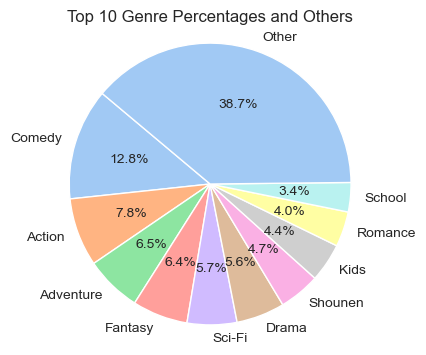

In [83]:
# Extract genres
genre_set = df['genre'].str.split(',', expand=True)
appended_rows = pd.concat([genre_set[i] for i in range(0, genre_set.shape[1])], ignore_index=True)
genre_final = pd.DataFrame({'genre': appended_rows.dropna().unique()})


# Function to clean genre names (handle leading/trailing spaces)
def clean_genre_name(genre):
  if isinstance(genre, str):
      return genre.strip()
  return genre

#Clean the genre_set
for i in range(genre_set.shape[1]):
    genre_set[i] = genre_set[i].apply(clean_genre_name)
# Flatten the genres
flat_genres = genre_set.values.flatten()

# Remove NaN and create a series of all genres
all_genres = pd.Series(flat_genres).dropna()

# Count the occurrences of each genre
genre_counts = all_genres.value_counts()

# Calculate the percentage of each genre
genre_percentages = (genre_counts / genre_counts.sum()) * 100

# Select the top 5 genres
top_10_genres = genre_percentages.head(10)

# Calculate the percentage of the remaining genres
other_genres_percentage = genre_percentages[10:].sum()

# Create labels for the pie chart
labels = top_10_genres.index.tolist() + ['Other']

# Create data for the pie chart
sizes = top_10_genres.tolist() + [other_genres_percentage]

# Create the pie chart
plt.figure(figsize=(4, 4))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Top 10 Genre Percentages and Others')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()



We notice that Comedy (12.8%), Action (7.8%), Adveneture (6.5%) and Fantasy(5.7%) are the most common genres in our anime list.


We will perform the following:
* For genres & type: We will replace missing values with "Unknown" since these are categorical features used for similarity computation.
* For ratings: We fill missing ratings using the median rating
* For episodes: We have already converted the unknown value to NaN. We will perform context-aware imputation based on the type.

In [84]:
# Replace missing values in categorical columns
df['genre'] = df['genre'].fillna("Unknown")
df['type'] = df['type'].fillna("Unknown")


In [85]:
# Fill missing ratings with the median rating value
df['rating'] = df['rating'].fillna(df['rating'].median())

In [86]:

# Group by 'type' and compute median episode count for each category
type_median_episodes = df.groupby('type')['episodes'].median()
# Fill missing episode counts with the median based on type
df['episodes'] = df.apply(lambda row: type_median_episodes[row['type']] if pd.isna(row['episodes']) else row['episodes'], axis=1)

In [87]:

df.isnull().sum()

anime_id     0
name         0
genre        0
type         0
episodes    25
rating       0
members      0
dtype: int64


The unknown value in episodes is due to unknown type possibly having unknown NaN episodes. This we will jsut impute with the general median.

In [89]:
#Imputing the remaining null values
df['episodes'] = df['episodes'].fillna(df['episodes'].median())

In [90]:
df.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

Processing Genre (Multi-Label Encoding)

genre is a list of strings (e.g., "Action, Comedy, Historical") rather than a structured format.
We need to compare anime based on genre similarity.


In [91]:
# Convert genres into multiple binary columns
from sklearn.preprocessing import MultiLabelBinarizer

# Split genre strings into lists
df['genre'] = df['genre'].apply(lambda x: x.split(', ') if isinstance(x, str) else [])

# Use MultiLabelBinarizer to create genre binary columns
mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(mlb.fit_transform(df['genre']), columns=mlb.classes_)

In [92]:
df_copy =df.copy()
# Concatenate with original dataframe
df = pd.concat([df, genre_encoded], axis=1)
df = df.drop(columns=['genre'])  # Drop original genre column

In [93]:
df.head()

,anime_id,name,type,episodes,rating,members,Action,Adventure,Cars,Comedy,...,Slice of Life,Space,Sports,Super Power,Supernatural,Thriller,Unknown,Vampire,Yaoi,Yuri
0,32281,Kimi no Na wa.,Movie,1.0,9.37,200630,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,5114,Fullmetal Alchemist: Brotherhood,TV,64.0,9.26,793665,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,28977,Gintama°,TV,51.0,9.25,114262,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,9253,Steins;Gate,TV,24.0,9.17,673572,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,9969,Gintama&#039;,TV,51.0,9.16,151266,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [96]:
from sklearn.preprocessing import LabelEncoder

# Encode 'type' into numeric values
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])
df = df.drop(columns=['type'])  # Drop original type column

In [98]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Normalize numerical columns
df[['rating', 'members', 'episodes']] = scaler.fit_transform(df[['rating', 'members', 'episodes']])

In [99]:
df.head()

,anime_id,name,episodes,rating,members,Action,Adventure,Cars,Comedy,Dementia,...,Space,Sports,Super Power,Supernatural,Thriller,Unknown,Vampire,Yaoi,Yuri,type_encoded
0,32281,Kimi no Na wa.,-0.247980,2.845534,3.330241,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,5114,Fullmetal Alchemist: Brotherhood,1.114236,2.737388,14.148406,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,5
2,28977,Gintama°,0.833144,2.727556,1.754713,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,5
3,9253,Steins;Gate,0.249337,2.648904,11.957666,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,5
4,9969,Gintama&#039;,0.833144,2.639073,2.429742,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,5




The dataset has been appropriately pre-processed to prepare it for building our recommendation system model.


In [101]:
# Step 1: Feature Selection
features = ['rating', 'type_encoded']  # Numerical features
features.extend(mlb.classes_)  # Add all genre binary columns
features

['rating',
 'type_encoded',
 'Action',
 'Adventure',
 'Cars',
 'Comedy',
 'Dementia',
 'Demons',
 'Drama',
 'Ecchi',
 'Fantasy',
 'Game',
 'Harem',
 'Hentai',
 'Historical',
 'Horror',
 'Josei',
 'Kids',
 'Magic',
 'Martial Arts',
 'Mecha',
 'Military',
 'Music',
 'Mystery',
 'Parody',
 'Police',
 'Psychological',
 'Romance',
 'Samurai',
 'School',
 'Sci-Fi',
 'Seinen',
 'Shoujo',
 'Shoujo Ai',
 'Shounen',
 'Shounen Ai',
 'Slice of Life',
 'Space',
 'Sports',
 'Super Power',
 'Supernatural',
 'Thriller',
 'Unknown',
 'Vampire',
 'Yaoi',
 'Yuri']

### Recommendation System:

Design a function to recommend anime based on cosine similarity.
Given a target anime, recommend a list of similar anime based on cosine similarity scores.
Experiment with different threshold values for similarity scores to adjust the recommendation list size.
Analyze the performance of the recommendation system and identify areas of improvement.


In [104]:
from sklearn.metrics.pairwise import cosine_similarity

# Step 2: Compute Cosine Similarity Matrix
cosine_sim = cosine_similarity(df[features])  # Compute similarity matrix

# Convert similarity matrix into a DataFrame
similarity_df = pd.DataFrame(cosine_sim, index=df['name'], columns=df['name'])

In [ ]:
Implementing the Recommendation Function

We create a function that:

    Takes an anime title as input.
    Finds similar anime using cosine similarity.
    Returns top N recommendations.

We will set the similarity threshold to be 0.5 for now. And obtain the top 10 similar values.

In [105]:
def recommend_anime(anime_name, top_n=10, similarity_threshold=0.5):
    
    if anime_name not in similarity_df.index:
        return f"Anime '{anime_name}' not found in dataset."

    # Get similarity scores for the given anime
    similar_scores = similarity_df[anime_name].sort_values(ascending=False)

    # Filter by threshold and return top N recommendations
    recommended_anime = similar_scores[similar_scores > similarity_threshold].iloc[1:top_n+1]

    return recommended_anime

In [106]:
anime = recommend_anime("Kimi no Na wa.", top_n=10, similarity_threshold=0.5)
anime

name
Kokoro ga Sakebitagatterunda.          0.935577
Hotarubi no Mori e                     0.889770
Mirai ni Mukete: Bousai wo Kangaeru    0.866301
Koe no Katachi                         0.862664
Sen to Chihiro no Kamikakushi          0.858228
Tsumiki no Ie                          0.853518
Momo e no Tegami                       0.850772
Harmonie                               0.845561
Michi                                  0.840121
Oshin                                  0.837404
Name: Kimi no Na wa., dtype: float64



We obtained a list of the top 10 similar animes to this movie. We notice that the similarity score is all above 0.79, which is great. We can cross check this list in the original dataset and notice the similarity there.


In [108]:
sim_anime = anime.index.tolist()
sim_anime.append('Kimi no Na wa.')

df[df['name'].isin(sim_anime)]

,anime_id,name,episodes,rating,members,Action,Adventure,Cars,Comedy,Dementia,...,Space,Sports,Super Power,Supernatural,Thriller,Unknown,Vampire,Yaoi,Yuri,type_encoded
0,32281,Kimi no Na wa.,-0.247980,2.845534,3.330241,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
11,28851,Koe no Katachi,-0.247980,2.530926,1.544401,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15,199,Sen to Chihiro no Kamikakushi,-0.247980,2.412948,8.175764,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
60,10408,Hotarubi no Mori e,-0.247980,2.098340,3.272031,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
208,28725,Kokoro ga Sakebitagatterunda.,-0.247980,1.813226,0.758516,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
244,5365,Tsumiki no Ie,-0.247980,1.764068,0.494681,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
894,10389,Momo e no Tegami,-0.247980,1.282324,0.227071,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1494,20903,Harmonie,-0.247980,1.026705,0.199890,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
9532,7616,Michi,-0.183112,1.498617,-0.326247,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9577,33980,Mirai ni Mukete: Bousai wo Kangaeru,-0.247980,2.481768,-0.328253,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [118]:
anime = recommend_anime("Death Note", top_n=10, similarity_threshold=0.75)
anime

name
Death Note Rewrite               0.991789
Higurashi no Naku Koro ni Kai    0.984411
Mousou Dairinin                  0.972214
Higurashi no Naku Koro ni        0.966690
Jigoku Shoujo Mitsuganae         0.959891
Boku dake ga Inai Machi          0.956247
Zankyou no Terror                0.953315
Mirai Nikki (TV)                 0.950457
Jigoku Shoujo Futakomori         0.950179
Shiki                            0.948404
Name: Death Note, dtype: float64

In [119]:
sim_anime = anime.index.tolist()
sim_anime.append('Death Note')

df[df['name'].isin(sim_anime)]

,anime_id,name,episodes,rating,members,Action,Adventure,Cars,Comedy,Dementia,...,Space,Sports,Super Power,Supernatural,Thriller,Unknown,Vampire,Yaoi,Yuri,type_encoded
40,1535,Death Note,0.530429,2.196655,18.166251,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,5
49,31043,Boku dake ga Inai Machi,-0.010132,2.137666,7.010590,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,5
144,1889,Higurashi no Naku Koro ni Kai,0.249337,1.901709,3.648948,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,5
250,23283,Zankyou no Terror,-0.031755,1.754237,5.925408,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,5
334,934,Higurashi no Naku Koro ni,0.292582,1.665753,6.228244,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,5
436,1594,Jigoku Shoujo Futakomori,0.292582,1.577270,1.126348,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,5
445,10620,Mirai Nikki (TV),0.292582,1.567438,11.658825,1,0,0,0,0,...,0,0,0,1,1,0,0,0,0,5
541,7724,Shiki,0.206092,1.488786,4.250789,0,0,0,0,0,...,0,0,0,1,1,0,1,0,0,5
778,2994,Death Note Rewrite,-0.226357,1.341313,1.288392,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,4
833,3713,Jigoku Shoujo Mitsuganae,0.292582,1.311819,0.746494,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,5


Performance evaluation goes beyond simple accuracy metrics and should include ranking and behavioral metrics.

### Interview Questions:

#### 1. Can you explain the difference between user-based and item-based collaborative filtering?

User-based collaborative filtering (UBCF) recommends items by finding users with similar tastes
Item-based collaborative filtering (IBCF) recommends items similar to those a user has liked in the past.
UBCF is best for small, static datasets, while IBCF is more scalable, stable, and better at handling sparse data.

**Key Differences:**

  * **Logic:** UBCF asks "Who is like me?", whereas IBCF asks "What is like what I liked?".
  * **Recommendation Basis:** UBCF finds similar users (rows in a user-item matrix), while IBCF finds similar items (columns in a user-item matrix).
  * **Stability & Scalability:** Item-based is generally more stable because item relationships change less frequently than user behaviors. It is also better for large, sparse datasets, as it often requires less computing online.
  * **Cold Start Problem:** IBCF often handles new user cold-start issues better because it can recommend items based on a few initial interactions, whereas UBCF requires a history of similar user behavior

**Pros and Cons Summary:**


|Feature 	|User-Based (UBCF)	|Item-Based (IBCF)|
|---|---|---|
|Best Used For	|Smaller communities, niche recommendations	|Large platforms with many users|
|Stability	|Low (user preferences change frequently)	|High (item similarity is relatively constant)|
|Scalability	|Less scalable	|More scalable|
|Explainability	|Harder to explain	|Easier to explain ("Because you bought X...")|
|Pros	|High personalization	|Better handles sparsity and cold start|
|Cons	|Struggles with high sparsity	|Can lead to less diverse recommendations|

#### 2. What is collaborative filtering, and how does it work?

Collaborative filtering is
a recommendation method that predicts a user's interests by analyzing the preferences and behaviors of many other users. It operates on the principle that if users shared similar tastes in the past, they will likely have similar preferences for new items in the future. This technique is widely used by companies like Amazon and Netflix for personalizing user experience.

**How It Works**

**The process typically involves the following steps:**
   1. Collect Data: User interactions, such as ratings, purchases, or views (explicit or implicit feedback), are gathered and stored in a user-item matrix. Rows represent users, columns represent items, and values indicate interactions or ratings.
   2. Find Similarities: The algorithm calculates how similar users are to each other (user-based) or how similar items are to each other (item-based) using similarity metrics like cosine similarity or the Pearson correlation coefficient.
   3. Generate Recommendations: Based on the similarity scores, the system identifies a group of "neighbors" (similar users or items). It then recommends items that the target user hasn't interacted with yet but which the neighbors liked.